## Building thermics project
2026-05-11
### Authors:
Bengtström, Anton -
Granfelt, Hannes -
Stickl, Nicolas -
Ghosn, Elias


#### Project links

**GitHub repository:** [Smart-Cities GitHub Repository](https://github.com/HannesGra/Smart-Cities)

**Binder repository:** [Open Smart-Cities in Binder](https://mybinder.org/v2/gh/HannesGra/Smart-Cities/HEAD)

#### Contents

- 1. Description of the building (drawing, dimensions, materials, material properties, etc.)
- 2. Hypothesis (location, boundary conditions, schedule for usage, etc.)
- 3. Thermal model
- 4. Mathematical model: Differential Algebraic Equations (matrices A, G, and C, vectors b and f) and state-space representation (matrices A, B, C and D and vector u).
- 5. Model implementation in Python.
- 6. Steady-state results.
- 7. Dynamic simulation results
- 8. Time step and settling time
- 9. Optimization (e.g., insulation, HVAC control, ventilation rate, solar shading)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dm4bem

## 1. Description of the building

The building is made up of two cubical rooms. Room 1 is a storage room and room 2 is a living room with a window. The walls of room 1 are non-insulated and the walls of room 2 are insulated. The walls have length l and width w. A grapichal representation of the rooms is shown below.

![Buildning](Buildning.png)

Figure 1: The building

The dimensions of the building are:

- $l = 3\,  \mathrm{m}$, lengths and height of all walls.
- $w = 0.20 \, \mathrm{m}$, width of the walls.

In [2]:
l = 3                 # m length and height of walls
w_concrete = 0.2             # m thickness of concrete walls
w_insulation = 0.08          # m thickness of insulation
w_glass = 0.04               # m thickness of glass

# surface areas
S = l**2              # m² surface area of the walls
S_glass = S           # m² surface area of the glass wall
S_insu = 2 * S        # m² surface area of concrete & insulation of room 2
S_noninsu = 3 * S     # m² surface area of concrete of room 1
S_indoor = S          # m² surface area of indoor wall

![Description of the building](Model_of_building.png)

Figure 2: Description of the building

### 1.1 Material properties

The walls consist of three different material: concrete, insulation and glass. These material have different thermo-physical properties which are presented below. The short-wave solar radiation and different outside temperatures and setpoint temperatures are also presented here.

In [3]:
# Thermo-physical propertites of the walls

## Thermal conductivities
λ_concrete = 1.4             # W/(m K) wall thermal conductivity
λ_insulation = 0.027         # W/(m K) insulation thermal conductivity
λ_glass = 1.4                # W/(m K) glass thermal conductivity

## Densitites
ρ_concrete = 2300   # kg/m^3
ρ_glass = 2500      # kg/m^3
ρ_insulation = 55   # kg/m^3

## Heat capacities
c_insulation = 1210 # J/Kg*K   
c_concrete = 880    # J/Kg*K
c_glass = 1210      # J/Kg*K

# Thermo-physical properties of air

ρ_air, c_air = 1.2, 1000    # kg/m3, J/(kg K) density, specific heat air
hi, ho = 8, 25      # W/(m2 K) convection coefficients in, out

# outdoor temperature °C 
To = 30 

# indoor temperature set-point °C
Ti_sp = 20          # Occupancy

# ventilation rate (air-changes per hour)
ACH = 1             # volume/h

# Solar radiation properties
α_gSW = 0.38    # short wave absortivity, glass
τ_gSW = 0.30    # short wave transmitance, glass
α_wSW = 0.25    # short wave absortivity: white smooth surface



## 2. Hypotheses

In order to properly simulate the buidlings thermics differnet scenarios are to be simulated. In order to size the HVAC system it is important to know the max heating and cooling load that the building will experience. In order to know the yearly energy consumption the mean temperature of the seasons need to be known.  This is heavily dependant on the outside temperature $T_0$. Therefore it is assumed that the building is located in Marseille and corresponding weather data will be used for the simulations. It is assumed that autumn and spring are similar in terms of weather so three differnet seasons will be studied. Besides $T_0$ it is also important to consider solar radiation which will differ during the year. For simplicity a short wave radiation ratio is introduced which represents the ratio of solar irradince to the maximum solar irradince. The short wave radiation ratio is assumed to be 1.0 during peak summer day and 0.0 during a winter night. For the mean season scenarios 0.2, 0.5 and 0.7 are asuumed for winter, spring/ fall and summer respectively. It is also important to consider occupants in the building. For this simualtion it is assumed that one peson lives in the building. A person generates 80W of heat which will need to taken into account. The floor and ceiling of the building are assumed to be adiabatic for simplicitys sake.

Table 1: Steady State scenarios, predefined parameters
| Scenario | Description              | Short wave radiation ratio | Occupancy | Setpoint (°C) |
| -------- | ------------------------ | -------------------------- | --------- | ------------- |
| 1        | Winter peak heating      | 0.0                        | 1         | 20            |
| 2        | Summer peak cooling      | 1.0                        | 1         | 20            |
| 3        | Winter no occupancy      | 0.0                        | 0         | 15            |
| 4        | Summer no occupancy      | 1.0                        | 0         | 0.0           |
| 5        | Fall / Spring            | 0.5                        | 1         | 20            |
| 6        | Summer mean temp         | 0.7                        | 1         | 20            |
| 7        | Summer mean temp no occ. | 0.7                        | 0         | 0.0           |
| 8        | Winter mean temp         | 0.2                        | 1         | 20            |
| 9        | Winter mean temp no occ. | 0.2                        | 0         | 15            |


## 3. Thermal model
Below, we see the description of the thermal models with nodes and branches as well as all heat flows. The first model is a simplified version of figure 2, not taking the thermal capacitances into account and is therefore used for steady state simulations, see figure 3. The second model is the complete model taking the thermal capacitances into account and is used for dynamic simulations, see figure 4. It also has auxillary heat flow directly implemented in the model.

### 3.1 Steady state thermal model

A thermal network of a building is done using a weighted directed graph. The graph has edges and vertices representing how heat flows in the building and what homogeneous temperatures a volume, a surface, a line or a point in space in the building has, respectively. 

A temperture node $\theta_j$ is connected with heat flow rate branches $q_k, k = 0 ... n$ and heat flow rate sources $f_j$. A heat flow rate source is independent of temperature differences and could represent sunlight (solar radiation) or people inside the building (occupants) for instance. According to Kirchhoff's current law, the heat flow rates in and out of a node must always be equal to zero.

$$\sum_{k} q_k + f_j= 0$$

How much a heat flow rate becomes is governed by the conductance $G_k$ of the branch and the temperature sources $b_k$ such as the outdoor temperature and remains constant no matter how high or low the heat flow rate is. 

The directed sum of temperature differences over a branch results in the temperature drop over a conductance to be equal to

$$e_k = \theta_i - \theta_j + b_k$$

Furthermore, the relation connecting the temperature drop, $e_k$, over a conductance, $G_k$, and the heat flow rate through that conductance is:

$$q_k = G_k \, e_k$$

This is as mentioned before represented by a directed graph with:
- $A$ - incidence matrix;
- $G$ - conductance diagonal matrix;
- $b$ - vector of temperature sources;
- $f$ - vector of flow-rate sources.

This solves to

$$ \theta = (A^TGA)^{-1}(A^TGb + f)$$

and

$$ q = G(-A\theta + b)$$

![Thermal model ss](Heat_transfer_model.png)

Figure 3: Thermal model for steady state

### 3.2 Dynamic thermal model

After the steady state simulations the model is updated to include thermal capacitances. This model can handle dynamic simulations, meaning that it includes variations in time. In order to do this it is important to convert the system of equations into state-space representation. In state-space the system is defined by two equations, the state equation and the output equation, shown below.

$$
\left\{\begin{array}{rr}
\dot{\theta}_s=A_s \theta_s + B_s u\\ 
y = C_s \theta_s + D_s u
\end{array}\right.
$$

State space describes the system as a set of inputs, outputs and state variables related by first order differential equations. In order to be able to handle the transient behavior it is needed to convert the system of equations into this form. For this, we need a more complicated model, one that can take into account thermal capacitances. These will be placed inbetween the conductive layers, as marked in the figure below

![Thermal model s](Model2.png)

Figure 4: Thermal model for dynamic state

### 3.3. Weather data

In order to simulate the building properly, accurate weather data such as solar radiation and temperature is needed.

#### 3.3.1 Solar Radiation Calculations E
To find the maximum solar irridation on the walls used in the scenarios, the weather data is imported and the solar irridation on each walls for the hottest month July is calculated using the mean value of the entier month.



In [4]:
# Finding the maximum solar radiation on the walls
filename = 'FRA_Marseille.076500_IWEC.epw'
[data, meta] = dm4bem.read_epw(filename, coerce_year=None)

# Extract the month and year from the DataFrame index with the format 'MM-YYYY'
month_year = data.index.strftime('%m-%Y')

# Create a set of unique month-year combinations
unique_month_years = sorted(set(month_year))

# Create a DataFrame from the unique month-year combinations
pd.DataFrame(unique_month_years, columns=['Month-Year'])

# select columns of interest
weather_data = data[["temp_air", "dir_n_rad", "dif_h_rad"]]

# replace year with 2000 in the index 
weather_data.index = weather_data.index.map(
    lambda t: t.replace(year=2000))

# Define site and surface assumptions
albedo = 0.2
latitude = 43
slope = 90

azimuths = [0, 90, 180, -90]

labels = {
    0: "South",
    90: "West",
    180: "North",
    -90: "East"
}

# Create dictionary for July data
july_data = {}

for az in azimuths:
    surface_orientation = {
        'slope': slope,
        'azimuth': az,
        'latitude': latitude
    }

    rad_surf = dm4bem.sol_rad_tilt_surf(weather_data, surface_orientation, albedo)
    july_data[az] = rad_surf[rad_surf.index.month == 7]

summary = pd.DataFrame({
    az: {
        "Direct (W/m²)": july_data[az]["direct"].mean(),
        "Diffuse (W/m²)": july_data[az]["diffuse"].mean(),
        "Reflected (W/m²)": july_data[az]["reflected"].mean(),  
        "Total (W/m²)": (july_data[az]["direct"] + july_data[az]["diffuse"]).mean() + july_data[az]["reflected"].mean()
    }
    for az in azimuths
}).T

# Replace index with labeled version
summary.index = summary.index.map(labels)

print("\nMean July Solar Radiation by Orientation:\n")
print(summary.round(1).to_string())

# Extract average total radiation by orientation from the summary table
E_south_avg = summary.loc["South", "Total (W/m²)"]
E_west_avg  = summary.loc["West", "Total (W/m²)"]
E_north_avg = summary.loc["North", "Total (W/m²)"]
E_east_avg  = summary.loc["East", "Total (W/m²)"]

# compute the average max E value for all walls
E_noninsu = (E_south_avg + E_west_avg + E_north_avg) / 3
E_glass   = E_east_avg
E_insu    = (E_south_avg + E_north_avg) / 2

print("\nRadiation used in the model:\n")
print(f"E_noninsu = {E_noninsu:.1f} W/m²")
print(f"E_glass   = {E_glass:.1f} W/m²")
print(f"E_insu    = {E_insu:.1f} W/m²")



Mean July Solar Radiation by Orientation:

       Direct (W/m²)  Diffuse (W/m²)  Reflected (W/m²)  Total (W/m²)
South           59.0            45.1              58.2         162.2
West           107.9            45.1              58.2         211.2
North           10.8            45.1              58.2         114.0
East            46.3            45.1              58.2         149.6

Radiation used in the model:

E_noninsu = 162.5 W/m²
E_glass   = 149.6 W/m²
E_insu    = 138.1 W/m²


#### 3.3.2 Outdoor Temperature Calculations

From the weather data of Marseille the outdoor temperatures for the in Table 1 introduced scenarios are calculated. The mean temperatures for the seasons are calculated by taking the mean of the temperatures for the months of the season. The worst case conditions are found by isolationg the hottest and coldest day of the season and taking the mean temperature of this specific day.

In [5]:
# Define season scenarios
summer = weather_data[weather_data.index.month.isin([6, 7, 8])]
winter = weather_data[weather_data.index.month.isin([12, 1, 2])]
autumn_spring = weather_data[weather_data.index.month.isin([3, 4, 5, 9, 10, 11])]

# Compute mean temperatures
T_summer = summer["temp_air"].mean()
T_winter = winter["temp_air"].mean()
T_autumn_spring = autumn_spring["temp_air"].mean()

print("\nMean Outdoor Temperature by Season:\n")
print(f"T_summer = {T_summer:.1f} °C")
print(f"T_winter = {T_winter:.1f} °C")
print(f"T_autumn_spring = {T_autumn_spring:.1f} °C")

# Extract temperature only
temp = weather_data["temp_air"]

# Group by day and compute daily mean temperature
daily_mean_temp = temp.resample('D').mean()

# Find hottest and coldest days
hottest_day = daily_mean_temp.idxmax()
coldest_day = daily_mean_temp.idxmin()

T_hottest = daily_mean_temp.max()
T_coldest = daily_mean_temp.min()

print("\nExtreme Days:\n")
print(f"Hottest day: {hottest_day.date()} → {T_hottest:.1f} °C")
print(f"Coldest day: {coldest_day.date()} → {T_coldest:.1f} °C")


Mean Outdoor Temperature by Season:

T_summer = 23.2 °C
T_winter = 7.2 °C
T_autumn_spring = 14.4 °C

Extreme Days:

Hottest day: 2000-08-05 → 27.1 °C
Coldest day: 2000-02-20 → 0.4 °C


### 3.3.3 Scenario Data
The predifined input parameters of Table 1 and the temperatures derived from the weather data are organizedind a dataFrame. This dataFrame also serves as the object to save the result so and extra collumns of heatflow and indoor temeratures are implemented.

In [6]:
# Create the scenario data
data = {
    "Scenario": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "Description": [
        "Winter peak heating",
        "Summer peak cooling",
        "Winter no occupancy",
        "Summer no occupancy",
        "Fall / Spring",
        "Summer mean temp",
        "Summer mean temp no occ.",
        "Winter mean temp",
        "Winter mean temp no occ."
    ],
    "Short wave radiation ratio": [0, 1, 0, 1, 0.5, 0.7, 0.7, 0.2, 0.2],
    "Outdoor_Temp_C": [T_coldest, T_hottest, T_coldest, T_hottest, T_autumn_spring, T_summer, T_summer, T_winter, T_winter],
    "Occupancy": [1, 1, 0, 0, 1, 1, 0, 1, 0],
    "Setpoint_C": [20, 20, 15, 0, 20, 20, 0, 20, 15],
    "q": [np.nan] * 9,
    "Room_Temperature_Window_C": [np.nan] * 9,
    "Room_Temperature_Garage_C": [np.nan] * 9
}

# Create DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print("Scenario Outdoor Temperature:")
print(df[["Description", "Outdoor_Temp_C"]])


Scenario Outdoor Temperature:
                Description  Outdoor_Temp_C
0       Winter peak heating        0.358333
1       Summer peak cooling       27.062500
2       Winter no occupancy        0.358333
3       Summer no occupancy       27.062500
4             Fall / Spring       14.395719
5          Summer mean temp       23.180299
6  Summer mean temp no occ.       23.180299
7          Winter mean temp        7.172639
8  Winter mean temp no occ.        7.172639


### 3.3.4 Dynamic weather input data for nonlinear simulation
To extract the dynamic weather input data, a similar structure as the one used in 3.3.1 is used, only now it is stored in its entierty and no average values calculated. This is done to be able to simulate the dynamic response of the building. 

In [7]:
# define a function for calculating the total radiation on a tilted surface
def tilted_total_radiation(azimuth):
    surface_orientation = {
        'slope': slope,
        'azimuth': azimuth,
        'latitude': latitude
    }
    rad = dm4bem.sol_rad_tilt_surf(weather_data, surface_orientation, albedo)
    return rad.sum(axis=1)

# calculate the total solar radiation in each radiation
E = {
    'south': tilted_total_radiation(0),
    'west': tilted_total_radiation(90),
    'north': tilted_total_radiation(180),
    'east': tilted_total_radiation(-90)
}

# calculate the solar radiation for each wall type
E_noninsu_tv = (E['south'] + E['west'] + E['north']) / 3
E_glass_tv = E['east']
E_insu_tv = (E['south'] + E['north']) / 2

# calculate the total surface area of indoor walls reached by sunlight
S_T = S_indoor + S_insu

# create the input data set (see section 4.7.2 and 7.1 for more information on this)
weather_inputs = pd.DataFrame({
    'To': weather_data['temp_air'], # outdoor temperature
    'Φo_1': α_wSW * E_noninsu_tv * S_noninsu, # solar radiation absorbed by noninsulated outdoor surface
    'Φi_1': τ_gSW * E_glass_tv * S_glass * S_indoor / S_T, # solar radiation absorbed by indoor wall through glass transmission
    'Qa': 0.0, # auxiliary heat gains
    'Φo_2': α_wSW * E_insu_tv * S_insu, # solar radiation absorbed by insulated outdoor surface
    'Φi_2': τ_gSW * E_glass_tv * S_glass * S_insu / S_T, # solar radiation absorbed by inside insulated wall through glass transmission
    'Φa': α_gSW * E_glass_tv * S_glass # solar radiation absorbed by glass
})

## 4. Mathematical model

Once the model is created and the necesarry inputs are defined the model can be solved. This is done by solving 

$$ \theta = (A^TGA)^{-1}(A^TGb + f)$$

and

$$ q = G(-A\theta + b)$$

which are matrix representations of the temperatures and heat flows. How to obtain the different matrices for this model is presented below.

### 4.1 The A-matrix

The incidence matrix shows how the edges/branches ($k$) are connected with the vertices/nodes ($j$) of the graph shown in figure 3. It can be written as:

$$
A_{k,j} = \begin{cases}
0 & \text{if } q_k \text{ is not connected to } \theta_j \\
+1 & \text{if } q_k \text{ enters node } \theta_j \\
-1 & \text{if } q_k \text{ leaves node } \theta_j
\end{cases}
$$

The incidence matrix is a sparce matrix (meaning it has a lot of zeros) which has:
- the number of rows equal to $n_q$, the number of flow rates $q_k$;
- the number of columns equal to $n_{\theta}$, the number of temperature nodes $\theta_j$.

### 4.2 Steady state incidence matrix

The incidence matrix of the simpler, steady state thermal model is created first. The number of flow rates and temperature nodes are:

In [8]:
nq, nθ = 13, 7  # number of flow-rates branches and of temperature nodes

In [9]:
A = np.zeros([nq, nθ])       # n° of branches X n° of nodes
A[0, 0] = 1                 
A[1, 6] = 1
A[2, 1] = 1
A[3, 1], A[3, 3] = -1, 1
A[4, 3] = 1
A[5, 2], A[5, 3] = -1, 1
A[6, 3], A[6, 5] = 1, -1
A[7, 0], A[7, 1] = -1, 1
A[8, 1], A[8, 2] = -1, 1
A[9, 3], A [9, 4] = 1, -1
A[10, 4] = 1
A[11, 5], A[11, 6] = 1, -1
A[12, 3] = 1


### 4.3 Conductances

The number of conductances correspond to the number of flows which is the number of rows of incidence matrix $A$

#### 4.3.1 Outdoor and indoor convection
Convection is the heat transfer through fluids. The convection conductances between the walls and the outdoor air are calculated as

$$
G_o = h_o S
$$

and for the indoor air

$$
G_i = h_i S
$$

The convection values are calculated below


In [10]:
G_o_noninsu = ho * S_noninsu #convection outdoor air non insulated wall
G_o_insu = ho * S_insu #convection outdoor air insulated wall
G_o_glass = ho * S_glass #convection outdoor air glass window
# G_o_indoor = ho * S_indoor #hypothecil convection between outdoor air and indoor wall (not used)

G_i_noninsu = hi * S_noninsu #convection indoor air non insulated wall
G_i_insu = hi * S_insu #convection indoor air insulated wall
G_i_glass = hi * S_glass #convection indoor air glass window
G_i_indoor = hi * S_indoor #convection indoor air indoor wall



#### 4.3.2 Conduction

Conduction is the heat transfer within a material or between two different materials. In the model there are three types of walls, concrete walls with insulation, concrete walls without insulation and a glass wall. If there is an insulated wall, the conduction is modeled as two conductances in series, one for the concrete and one for the insulation. For the non-insulated and the glass wall, it is just one conductance. The conductances are calculated as: 

$$
G = \frac{\lambda}{w}S
$$ 

where $\lambda$ is the conductivity of the material. In parallel, conductances are simply added. In series, they are added as $$\frac{1}{(1 / G1 + 1 / G2)}$$

Furthermore, since the node $\theta_4$ is in the middle of the glass, to account for the solar radiation absorbed by the glass, the conduction coefficient for each side of $\theta_4$ can be modeled as simply 2 $\cdot$ G where G is the conduction of the glass in this case.

In [11]:
G_cd_noninsu = λ_concrete * S_noninsu / w_concrete #Conduction of non-insulated walls

G_cd_insu_1 = λ_insulation * S_insu / w_insulation #Conduction of insulation layer of insulated walls
G_cd_insu_2 = λ_concrete * S_insu / w_concrete #Conduction of concrete layer of insulated walls
G_cd_insu = 1 / (1 / G_cd_insu_1 + 1 / G_cd_insu_2) #Conduction of insulated walls

G_cd_glass = λ_glass * S_glass / w_glass #Conduction of glass window

G_cd_indoor_1 = λ_concrete * S_indoor / w_concrete #Conduction of concrete layer of indoor walls
G_cd_indoor_2 = λ_insulation * S_indoor / w_insulation #Conduction of insulation layer of indoor walls
G_cd_indoor = 1 / (1 / G_cd_indoor_1 + 1 / G_cd_indoor_2) #Conduction of indoor walls

### 4.4 Ventilation: heat transfer by advection

Advection is the transport of a fluid. In this case, it is the transport of air. The volumetric flow rate of air circulating in room 2 results from the ventilation rate:

$$\dot V = L·l·H·\frac{ACH}{3600 \, \mathrm{s}}$$

The mass flow rate of air entering and getting out of room 2 is:

$$\dot m = \rho \dot V$$

There is ventilation and air flows moving air from outdoor -> window -> room 2 -> room 1 -> outdoor or vice versa.  The energy flow rate carried by the fluid is:

$$\dot H = \dot m c \theta$$

where:
- $\dot H$ is the enthalpy rate carried by the air, W;
- $\dot m$ - mass flow rate of the air, kg / s;
- $c$ - specific heat capacity of the air, J / (kg⋅K);
- $\theta$ - air temperature, °C.


#### 4.4.1 Air-flow: outdoor -> room 2 -> room 1 -> outdoor

If the airflow is from outdoor to room 2, then the heat flow rate transferred from outdoor air to the indoor air of room 2 is:

$$q_a = \dot m c T_o - \dot m c \theta_3$$

or

$$q_a = G(T_o - \theta_3)$$

where $G = \dot m c$.

The heat flow rate transferred by advection of the air from room 2 to room 1 is:

$$q_b = \dot m c \theta_3 - \dot m c \theta_1$$

or

$$q_b = G(\theta_3 - \theta_1)$$

where $G = \dot m c$.

#### 4.4.2 Air-flow: outdoor → room 1 → room 2 → outdoor

If the airflow is from room 1 to room 2 , then the heat flow rate transferred to the indoor air of room 2 is:

$$q_c = \dot m c \theta_1 - \dot m c \theta_3$$

or

$$q_c = G(\theta_1 - \theta_3)$$

where $G = \dot m c$.

The heat flow rate transferred by advection from the outdoor air to room 1 is:

$$q_d = \dot m c T_o - \dot m c \theta_1$$

or

$$q_d = G(T_o - \theta_1)$$

where $G = \dot m c.$

#### 4.4.3 Heat flow rate from room 1 to room 2

If the air flows from room 1 to room 2, then the heat flow rate is $q_c$ If the air flows from room 2 to room 1, then the heat flow rate is $q_b\equiv -q_c.$ Therefore, a single heat flow rate, $q_c$, is needed in the thermal network (Figure 3).

#### 4.4.4 Modelling the change in airflow direction

If the air flows in the direction: outdoor  → room 1 → room 2 → outdoor, then conductance $G$ at the outflow at the window is zero. Similarly, if the air flows in the direction: outdoor  → room 2 → room 1 → outdoor, then conductance $G$ at the noninsulated walls are 0. Other conducatances are $G = \dot m c$.

If there is no ventilation, all advection conductances are zero.

In [12]:
# convection conductances

V_dot = l**3 * ACH / 3600       # volumetric air flow rate
m_dot = ρ_air * V_dot               # mass air flow rate

G_advection = m_dot * c_air

### 4.5 Proportional controller

An HVAC system is modelled here as a simple proportional controller. It controls heat flow rate $q_{HVAC}$ to manage the indoor temperature $\theta_3$ (see figure 3). The heat flow rate is given by:

$$ q_{HVAC} = K_p (T_{i, sp} - \theta_i)$$

where:
- $K_p$ is the proportional gain of the controller, W/K;
- $T_{i, sp}$ - indoor setpoint temperature, °C 
- $\theta_i$ - indoor temperature, °C


The proportional controller can be represented as a conductance $K_p$ and a temperature source $T_{i, sp}$. If the conductance tends towards infinity, it becomes a perfect controller, and when it tends towards zero, the building becomes free-running.



*Note*: Respecting the sign convention for the flow rate, $q_{HVAC}$ is oriented from the lower to the higher potential of the temperature source $T_{i,sp}$.

In [13]:
# P-controler gain
controller_on = True

if controller_on:
    Kp = 1e4            # almost perfect controller Kp -> ∞
else:
    Kp = 0              # no gain, free running


### 4.6 The final G-matrix for steady state

The G-matrix is  a diagonal matrix of all conductances in the model. Now that all conductances can be calculated the G-matrix can be finalized. Some convections, conductions and advections need to be added together because they are in series or parallel.

In [14]:
# Conductance matrix
# ==================
G = np.zeros(A.shape[0])

G[0] = G_o_noninsu # convection outdoor non-insulated walls
G[1] = G_o_insu # convection outdoor insulated walls

G[5] = G_i_indoor # convection indoor walls
G[6] = G_i_insu # convection inside on insulated walls
G[7] = 1 / (1 / G_cd_noninsu + 1 / G_i_noninsu) # conduction non-insulated walls + convection inside on non-insulated walls
G[8] = 1 / (1 / G_cd_indoor + 1 / G_i_indoor) # conduction indoor walls + convection inside on indoor walls

G[9] = 1 / (1 / (2 * G_cd_glass) + 1 / G_i_glass) # conduction glass + convection inside on glass
G[10] = 1 / (1 / (2 * G_cd_glass) + 1 / G_o_glass) # conduction glass + convection outside on glass
G[11] = G_cd_insu # conduction insulated walls
G[12] = Kp # controller gain

# Advection conductances
G[[2, 3, 4]] = G_advection
# ====================


###  4.7 The b and f vector

The b and f vectors represent the sources in the model. The b vector is for the temperature sources and the f vector is for the heat flow rate sources.

#### 4.7.1 Vector of temperature sources b
The edges in the directed graph has only non-zero temperature sources since the setpoint temperature is set to $0^oC$. This means the number of temperature sources is equal to the number of edges represented by the rows of the incidence


In [15]:
# Vector of temperature sources
# =============================
b = np.zeros(A.shape[0])


b[[0, 1, 2, 4, 10]] = To
b[12] = Ti_sp

print(b)

[30. 30. 30.  0. 30.  0.  0.  0.  0.  0. 30.  0. 20.]


#### 4.7.2 Vector of flow-rate sources f

Furthermore, the heat flow rate sources are the solar irridation absorbed by the exterior walls, the irridation absorbed by the glass and the irridation absorbed by the inner walls passsing through the window. The number of heat flow rate sources is equal to the number of nodes, i.e., the number of columns of the incidence matrix $A$. The solar irridation absorbed by the exterior walls, i.e. $f = E \, S_o$.

The light passing through the glass will heat the inside walls. This will effect nodes 2 and 4 and depends on the surface areas as well as the transmitting properties of the glass wall.

In [16]:
f = np.zeros(nθ)

# solar radiation absorbed by non-insulated walls
f_noninsu = α_wSW *  E_noninsu * S_noninsu

# solar radiation absorbed by insulated walls
f_insu = α_wSW * E_insu * S_insu

f[0] = f_noninsu
f[6] = f_insu

# Solar radiation absorbed by the glass and transmitted through the glass
Q_solar_trans = τ_gSW * E_glass * S_glass # Solar radiation transmitted through the glass
Q_solar_abs = α_gSW * E_glass * S_glass # Solar radiation absorbed by the glass

S_T = S_indoor + S_insu # Total surface area of the sunlit indoor walls

f[2] = Q_solar_trans * S_indoor / S_T # heat sources from the transmitted solar radiation on indoor wall
f[5] = Q_solar_trans * S_insu / S_T # heat sources from the transmitted solar radiation on insulated wall

f[4] = Q_solar_abs # heat sources from the absorbed solar radiation by the glass

## 5. Steady State Results

We now name our nodes to improve readings and solve for:

$$ \theta = (A^TGA)^{-1}(A^TGb + f)$$

and

$$ q = G(-A\theta + b)$$


In [17]:
ventilation = [2, 3, 4] # indexes of ventilation branches
G[ventilation] = 0, m_dot * c_air, m_dot * c_air  # node 2 0 if flow from room 2 to room 1, node 4 0 if flow from room 1 to room 2

# Indexes of outputs
# ==================
indoor_air = [0, 3]   # indoor air temperature nodes
controller = [12]     # controller branch

θ_first_sim = np.linalg.inv(A.T @ np.diag(G) @ A) @ (A.T @ np.diag(G) @ b + f)
q_first_sim = np.diag(G) @ (-A @ θ_first_sim + b)


np.set_printoptions(suppress=True)
print("θ:", θ_first_sim[indoor_air], "°C")
print("q:", q_first_sim[controller], "W")

θ: [31.45585752 20.12609578] °C
q: [-1260.95777221] W


The function simulate_scenarios is used to iterate through all the scenarios in the DataFrame and compute the heat flow rate and indoor temperatures. It adjusts the respective matrices and uses the same calculation as previosly shown for an example case.

In [18]:
def simulate_scenarios(df, A, G_base, b_base, f_base, Kp, indoor_air, controller):
    """
    Iterates through all scenarios in the DataFrame and computes q and room temperature.

    Parameters:
    df : pandas.DataFrame
        Input DataFrame with scenarios
    A : np.ndarray
        System matrix
    G_base : np.ndarray
        Base conductance vector (will be copied per scenario)
    b_base : np.ndarray
        Base source vector (will be copied per scenario)
    f-base : np.ndarray
        Flow/source vector (will be copied per scenario)
    Kp : float
        Controller gain
    indoor_air : int
        Index of indoor air temperature in theta
    controller : int
        Index of controller heat flow in q

    Returns:
    df : pandas.DataFrame
        Updated DataFrame with computed q and room temperature
    """

    for idx, row in df.iterrows():
        # Copy base vectors to avoid overwriting
        G = G_base.copy()
        b = b_base.copy()
        f = f_base.copy()

        # Assign outdoor temperature
        b[[0, 1, 2, 4, 10]] = row["Outdoor_Temp_C"]

        # Assign setpoint
        b[12] = row["Setpoint_C"]

        # Assign solar radiation factors
        f *= row["Short wave radiation ratio"]

        

        # Controller activation
        if not row["Setpoint_C"] == 0:
            G[12] = Kp
        else:
            G[12] = 0

        # Solve system
        theta = np.linalg.inv(A.T @ np.diag(G) @ A) @ (
            A.T @ np.diag(G) @ b + f
        )

        q = np.diag(G) @ (-A @ theta + b)
        if row["Occupancy"]:
            q[controller] -= 80
            # print(f'Scenario: {row["Scenario"]}')

        # Store results
        df.at[idx, "Room_Temperature_Window_C"] = theta[3]
        df.at[idx, "Room_Temperature_Garage_C"] = theta[0]
        df.at[idx, "q"] = q[controller]

    return df

In [19]:
df = simulate_scenarios(df, A, G, b, f, Kp, indoor_air, controller)
for _, row in df.iterrows():
    print(f"Scenario {int(row['Scenario'])}: {row['Description']}")
    print(f"  Room Temperature: {row['Room_Temperature_Window_C']:.2f} °C")
    print(f"  Garage Temperature: {row['Room_Temperature_Garage_C']:.2f} °C")
    print(f"  q (heat flow): {row['q']:.2f} W")
    print("-" * 50)
    df

Scenario 1: Winter peak heating
  Room Temperature: 19.86 °C
  Garage Temperature: 0.66 °C
  q (heat flow): 1310.66 W
--------------------------------------------------
Scenario 2: Summer peak cooling
  Room Temperature: 20.11 °C
  Garage Temperature: 28.56 °C
  q (heat flow): -1132.98 W
--------------------------------------------------
Scenario 3: Winter no occupancy
  Room Temperature: 14.90 °C
  Garage Temperature: 0.58 °C
  q (heat flow): 1036.65 W
--------------------------------------------------
Scenario 4: Summer no occupancy
  Room Temperature: 34.87 °C
  Garage Temperature: 28.79 °C
  q (heat flow): 0.00 W
--------------------------------------------------
Scenario 5: Fall / Spring
  Room Temperature: 19.99 °C
  Garage Temperature: 15.28 °C
  q (heat flow): 40.32 W
--------------------------------------------------
Scenario 6: Summer mean temp
  Room Temperature: 20.06 °C
  Garage Temperature: 24.26 °C
  q (heat flow): -692.23 W
----------------------------------------------

## 5.1 Thermal load in steady-state.

To dimension the HVAC system the worst case operating point for heating and cooling needs to be found. This is done by taking the average temperature of the hottest and coldest day of the season. The mean temperature is used since in steady state it is only possible to simulate for one temperature so the mean temperature is used to simulate the difference between the hottest and coldest point of the day.

In order to estimate the yearly energy consumption of the HVAC system, the mean temperature of the seasons are used. The mean temperature of the season is calculated for summer, winter and fall/spring. This gives a more realisitic outdoor temperature for the whole year.

### 5.1.1 Peak Load Scenarios for HVAC Sizing

The two worst-case scenarios are represented by Scenario 1 and Scenario 2.

**Scenario 1 – Peak Heating (Winter):**  
This scenario models the maximum heating demand during winter conditions.  
- A high temperature gradient of 20 °C between indoor and outdoor conditions is assumed.  
- The room is unoccupied, but temperature control is maintained at the setpoint.  
- Solar radiation is neglected (winter night assumption).  

This results in a required heating power of:

$$
P_{\text{heating}} =  1310 \ \text{W}
$$

**Scenario 2 – Peak Cooling (Summer):**  
This scenario represents the maximum cooling demand during summer conditions.  
- High outdoor temperature is considered.  
- Maximum solar radiation occurs (midday conditions).  
- Internal heat gains from occupancy are included.  

This results in a required cooling power of:

$$
P_{\text{cooling}} = 1133 \ \text{W}
$$

### 5.1.2 Conclusion

The HVAC system must be sized to handle these peak loads.  
Therefore, it should be capable of delivering at least:
- heating power **1,31 kW**  
- cooling power **1,13 kW**  

under worst-case operating conditions.

## 5.2 Annual HVAC Energy Calculation

The yearly HVAC energy demand is estimated using a scenario-based approach.  
Each scenario represents a typical operating condition (season, occupancy, temperature).

### 5.2.1 Methodology

- The thermal load `q` (in Watts) is calculated for each scenario.
- Each scenario is assigned a number of operating hours per year:
  - Fall/Spring: 2 × 2190 h
  - Summer: split into occupied and unoccupied periods (0.5 × 2190 h each)
  - Winter: split into occupied and unoccupied periods (0.5 × 2190 h each)

### 5.2.2 Energy Calculation

For each scenario:

$$
E_i = q_i \cdot t_i
$$

where:
- $q_i$ = thermal load (W)  
- $t_i$ = number of hours (h)

The total annual energy is then:

$$
E_{\text{year}} = \sum_i E_i
$$

Finally, the result is converted from Wh to kWh.

### 5.2.3 Assumptions

- Scenarios 1–4 (peak cases) are not included in annual energy, only for system sizing.
- The year is approximated using symmetric seasonal distributions.
- Constant load within each scenario.

In [20]:
# Define hours per scenario
hours_distribution = {
    5: 2 * 2190,          # Fall / Spring
    6: 0.5 * 2190,        # Summer mean temp
    7: 0.5 * 2190,        # Summer mean temp no occ.
    8: 0.5 * 2190,        # Winter mean temp
    9: 0.5 * 2190         # Winter mean temp no occ.
}

# Add hours column initialized to 0
df["hours"] = 0

# Assign hours to relevant scenarios
for scenario, hours in hours_distribution.items():
    df.loc[df["Scenario"] == scenario, "hours"] = hours

# Energy calculation (Wh)
df["Energy_Wh"] = abs(df["q"]) * df["hours"]

# Area calculation
living_area = l**2 * 2  # Two rooms

# Total yearly energy (convert to kWh)
total_energy_kWh = df["Energy_Wh"].sum() / 1000
total_operation_cost = total_energy_kWh * 0.18
specific_consumption = total_energy_kWh / living_area

print(f"Total HVAC energy per year: {total_energy_kWh:.2f} kWh")
print(f"For a constant tarif of 18ct/kWh, the total HVAC operation cost is: {total_operation_cost:.2f} €")
print(f"Specific consumption is: {specific_consumption:.2f} kW·h / m²")

Total HVAC energy per year: 2206.12 kWh
For a constant tarif of 18ct/kWh, the total HVAC operation cost is: 397.10 €
Specific consumption is: 122.56 kW·h / m²


## 6. Dynamic simulation with state space model
For the dynamic simulations, the second thermal model (see figure 4) needs to be used. It requires capacities to be added to the model, and all the previous matrices to be updated. The number of nodes and branches are also updated.

### 6.1 The A-matrix for dynamic state

As shown in figure 4, the number of nodes and branches are increased because of the added capacities. The new A matrix is thus updated to contain 18 branches and 12 nodes.

In [21]:
# Update the number of nodes and branches
nq = 18
nθ = 12
A = np.zeros([nq, nθ])       # n° of branches X n° of nodes


# Reconstruct the A matrix
A[0, 0] = 1
A[1, 0], A[1, 1] = -1, 1
A[2, 1], A[2, 2] = -1, 1
A[3, 2], A[3, 3] = -1, 1
A[4, 3], A[4, 4] = -1, 1
A[5, 4], A[5, 5] = -1, 1
A[6, 5], A[6, 6] = -1, 1
A[7, 6] = 1
A[8, 6], A[8, 7] = 1, -1
A[9, 7] = 1
A[10, 2] = 1
A[11, 2], A [11, 6] = -1, 1
A[12, 6] = 1
A[13, 6], A [13, 8] = 1, -1
A[14, 8], A [14, 9] = 1, -1
A[15, 9], A [15, 10] = 1, -1
A[16, 10], A [16, 11] = 1, -1
A[17, 11] = 1


print(A)

[[ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  1. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1. -1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.]]


### 6.2 The G-matrix for dynamic state

The G matrix can be recreated using already calculated variables. Before, the combined insulation and concrete conductances could be used, but now they need to be split up. Insead, G_cd_insu_1 is used for the insulation and G_cd_insu_2 for the concrete. The same goes for the indoor walls, G_cd_indoor_1 for the concrete and G_cd_indoor_2 for the insulation. The controller is turned off for the intital state-space representation.

In [22]:
# update the G matrix
G = np.zeros(nq)

G[0] = G_o_noninsu # Convection between outdoor air and non-insulated walls
G[1] = 2 * G_cd_noninsu # Conductance in half of the concrete in the non-insulated walls
G[2] = 1/(1/(2 * G_cd_noninsu) + 1/(G_i_noninsu)) # Conductance in half of the concrete in the non-insulated walls and 
                                                  # the convection with the inside
G[3] = 1 / (1 / G_i_indoor + 1 / (2 * G_cd_indoor_1)) # Convection with the inside and conductance in half of the concrete in the indoor walls
G[4] = 1 / (1 / (2 * G_cd_indoor_1) + 1 / (2 * G_cd_indoor_2)) # Conductance in half of the concrete in the indoor walls and half of the insulation
G[5] = 2 * G_cd_indoor_2 # Conductance in half of the insulation in the indoor wall
G[6] = G_i_indoor # Convection with the inside from the indoor wall
G[7] = Kp # Controller
G[8] = 1 / (1 / G_i_glass + 1 / (2 * G_cd_glass)) # Convection with the inside and conductance in half of the glass
G[9] = 1 / (1 / (2 * G_cd_glass) + 1 / G_o_glass) # Conductance in half of the glass and convection with the outside

G[13] = G_i_insu # Convection with the inside from the insulated wall
G[14] = 2 * G_cd_insu_1 # Conductance in half of the insulation in the insulated wall
G[15] = 1 / (1 / (2 * G_cd_insu_1) + 1 / (2 * G_cd_insu_2)) # Conductance in half of the insulation and half of the concrete in the insulated wall
G[16] = 2 * G_cd_insu_2 # Conductance in half of the concrete in the insulated wall
G[17] = G_o_insu # Convection with the outside from the insulated wall


# Ventilation
G[10] = m_dot * c_air # 0 
G[11] = m_dot * c_air 
G[12] = 0 # m_dot * c_air

### 6.3 Update the b matrix using strings

In [23]:
b = np.zeros(len(G), dtype=object)
b[[0, 9, 10, 12, 17]] = "To" # outdoor temoerature
b[7] = "Ti_sp" # setpoint temperature

### 6.4 Thermal capacitance

Now, the thermal capacitance matrix C is created. The equation for thermal capacity of a wall (in J/kg) is:

$$C_w= m_w c_w= \rho_w c_w w_w S_w$$

where:
- $m_w = \rho_w w_w S_w$ is the mass of the wall, kg;
- $c_w$ - specific heat capacity, J/(kg⋅K);
- $\rho_w$ - density, kg/m³;
- $w_w$ - width of the wall, m;
- $S_w$ - surface area of the wall, m².

New parameters are introduced and the capacitances of each wall are calculated and added to the C matrix.

In [24]:
# Calculate the volumes of the walls
V_insu_insulation = w_insulation * S_insu # Volume of insulation in insulated wall m^3
V_insu_concrete = w_concrete * S_insu # Volume of concrete in insulated wall m^3
V_noninsu = w_concrete * S_noninsu # Volume of concrete in non-insulated wall m^3
V_indoor_insulation = w_insulation * S_indoor # Volume of insulation in indoor wall m^3
V_indoor_concrete = w_concrete * S_indoor # Volume of concrete in indoor wall m^3
V_glass = w_glass * S_glass # Volume of glass in glass wall m^3


# Create the C matrix
# ==============
C = np.zeros(nθ)

# Calculate the thermal capacities of the walls
C_insu_insulation = ρ_insulation * V_insu_insulation * c_insulation # Thermal capacity of insulation in insulated wall J/K
C_insu_concrete = ρ_concrete * V_insu_concrete * c_concrete # Thermal capacity of concrete in insulated wall J/K
C_noninsu = ρ_concrete * V_noninsu * c_concrete # Thermal capacity of concrete in non-insulated wall J/K
C_indoor_insulation = ρ_insulation * V_indoor_insulation * c_insulation # Thermal capacity of insulation in indoor wall J/K
C_indoor_concrete = ρ_concrete * V_indoor_concrete * c_concrete # Thermal capacity of concrete in indoor wall J/K
C_glass = ρ_glass * V_glass * c_glass # Thermal capacity of glass in glass wall J/K

C[1] = C_noninsu
C[3] = C_indoor_concrete
C[4] = C_indoor_insulation
C[7] = C_glass
C[9] = C_insu_insulation
C[10] = C_insu_concrete 
# ==============

### 6.5 Update the f matrix using strings

In [25]:
f = np.zeros(nθ, dtype=object)
f[[0, 5, 6, 7, 8, 11]] = ["Φo_1", "Φi_1", "Qa", "Φa", "Φi_2", "Φo_2"]

### 6.6 Create a y matrix

In [26]:
y = [0,0,1,0,0,0,1,0,0,0,0,0] # we decide to look at node 2 and 6 (the indoor temperature)

### 6.7 Thermal Circuit to State-Space Conversion

Instead of using the dm4bem function `def file2TC(TC_file, name="w_", auto_number=False):` we will create the TC file using the matrices. This is then inputted into the `tc2ss(TC)` function to get the state-space matrices $A_s$, $B_s$, $C_s$, $D_s$ and $u_s$.

In [27]:
# Define labels
q = [f"q{i}" for i in range(len(G))]      # heat flows
θ = [f"θ{i}" for i in range(len(C))]      # temperatures

# Convert to pandas structures
A = pd.DataFrame(A, index=q, columns=θ, dtype=float)
G = pd.Series(G, index=q, dtype=float)
C = pd.Series(C, index=θ, dtype=float)
b = pd.Series(b, index=q)
f = pd.Series(f, index=θ)
y = pd.Series(y, index=θ, dtype=int)

# Pack into TC format
TC = {
    "A": A,
    "G": G,
    "C": C,
    "b": b,
    "f": f,
    "y": y
}

# Convert to state-space using the tc2ss function
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

## 7. Dynamic model to steady state

### 7.1 DAE to steady state
As a first step, the original DAE is used to get the steady-state temperatures.

In [28]:
diag_G = pd.DataFrame(np.diag(G), index=G.index, columns=G.index)

# Steady-state b matrix
bss = np.zeros(len(G))
bss[[0, 9, 10, 12, 17]] = To   # To outside temperature
bss[7] = Ti_sp                 # Ti_sp indoor temperature setpoint

# Steady-state f vector
fss = np.zeros(nθ)

# Turn on heat flows
Φo_1 = E_noninsu * S_noninsu # solar radiation absorbed by the outdoor surface of the non-insulated wall 
Φi_1 = Q_solar_trans * S_indoor / S_T # solar radiation absorbed by the indoor wall (transmitted through the glass)
Qa = 0 # Auxiliary heat from occupents 0 to compare with the previous model
Φa = Q_solar_abs
Φi_2 = Q_solar_trans * S_insu / S_T # solar radiation aborbed by the insulated indoor walls (transmitted through the glass)
Φo_2 = E_insu * S_insu # solar radiation absorbed by the outdoor surface of the insulated wall 

fss[[0, 5, 6, 7, 8, 11]] = [Φo_1, Φi_1, Qa, Φa, Φi_2, Φo_2]

# Solve for steady-state temperatures
θss = np.linalg.inv(A.T @ diag_G @ A) @ (A.T @ diag_G @ bss + fss)
print(f'θss = {np.around(θss[[2, 6]], 2)} °C')


θss = [34.24 20.12] °C


### 7.2 State-space to steady state
The next step is to use the state space represetation to retrieve the steady state. This, can then be compare to the DAE steady state to see if the state-space representation behaves as expected.

#### 7.2.1 Assemble the u matrix
The input vector $u$ of the state-space representation is obtained by stacking the vectors $b_T$ and $f_Q$:

$$u = \begin{bmatrix} b_T \\ f_Q\end{bmatrix}$$

where:
- $b_T$ is a vector of the nonzero elements of vector $b$ of temperature sources. For the circuit presented in Figure 3, $b_T = [T_o, T_{i,sp}, T_o, T_o, T_o, T_o]^T$ corresponds to the edges 0, 7, 9, 10, 12 and 17, where:
    - $T_o$ - outdoor temperature, °C;
    - $T_{i,sp}$ - set-point temperaure for the indoor air, °C.
- $f_Q$ - vector of nonzero elements of vector $f$ of flow sources. Furthermore, for the circuit presented in Figure 3, $f_Q = [\Phi_o, \Phi_i, \dot{Q}_a, \Phi_a, \Phi_i, \Phi_o]^T$, corresponding to nodes 0, 5, 6, 7, 8 and 11, where:
    - $\Phi_o$ - solar radiation absorbed by the outdoor surface of the wall, W;
    - $\Phi_i$ - solar radiation absorbed by the indoor surface of the wall, W;
    - $\dot{Q}_a$ - auxiliary heat gains (i.e., occupants, electrical devices, etc.), W;
    - $\Phi_a$ - solar radiation absorbed by the glass, W.

*Note*: Zero in vectors $b$ and $f$ indicates that there is no source on the branch or in the node, respectively. However, a source can have the value zero.

In [29]:
bT = np.array([To, Ti_sp, To, To, To, To])
fQ = np.array([Φo_1, Φi_1, Qa, Φa, Φi_2, Φo_2])

uss = np.hstack([bT, fQ])

inv_As = pd.DataFrame(np.linalg.inv(As),
                      columns=As.index, index=As.index)
yss = (-Cs @ inv_As @ Bs + Ds) @ uss

yss_2 = float(yss.values[0]) # θ2 indoor air temperature
yss_6 = float(yss.values[1]) # θ6 indoor air temperature
print(f'yss_6 = {yss_6:.2f} °C')
print(f'yss_2 = {yss_2:.2f} °C')


print(f'Error between DAE and state-space: {abs(θss[6] - yss_6):.2e} °C')
print(f'Error between DAE and state-space: {abs(θss[2] - yss_2):.2e} °C')


yss_6 = 20.12 °C
yss_2 = 34.24 °C
Error between DAE and state-space: 3.55e-15 °C
Error between DAE and state-space: 0.00e+00 °C


## 8. Time step and settling time
After state-space representation has been obtained and the steady state understood the dynamic response to a step-input, meaning a sudden change in input is studied. This will provide insight into the transient behavior of the system, how it responds and how it eventually settles in to a new steady state. For this, an analysis on the time step and settling time is done based on the eigenvalues of the state-space incidence matrix As. The building is free running in the initial analysis.

### 8.1 Eigenvalue analysis
Numerical stability of the explicit Euler integration method is acheived when

$$
\left |  \lambda_i \Delta t + 1 \right | < 1, \forall \lambda_i, 
$$.

where $\lambda_i$ is the eigenvalues of $A_s$, $\Delta t$ is the time step and j is the imaginary unit. The $A_s$ matrix has only negative eigenvalues. With $T_i = - 1 / \lambda_i$ it can be rewritten as 
$$
0 <\Delta t < -\frac{2}{\min \lambda_i} = 
2 \min \left ( -\frac{1}{\lambda_i}  \right ) = 
2 \min T_i
$$


In [30]:
# Free running
Kp = 0

# Update state-space matrices
TC['G']['q7'] = Kp      # controller gain
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

In [31]:
# Eigenvalues analysis
λ = np.linalg.eig(As)[0]
print(λ) # verify all are negative

[-0.00015434 -0.00023873 -0.00023177 -0.00000888 -0.00002757 -0.00002278]


### 8.2 Time step

The max time step, $\Delta t_{max}$, is equal to two times the minimum time constant, $T_i$. A time step smaller than $\Delta t_{max}$ is chosen.

In [ ]:
# time step
Δtmax = 2 * min(-1. / λ)    # max time step for stability of Euler explicit mentioned before
dm4bem.print_rounded_time('Δtmax', Δtmax)
Δt = 3600  # imposed time step smaller than Δtmax

imposed_time_step = False

if imposed_time_step:
    dt = Δt
else:
    dt = dm4bem.round_time(Δtmax)

dm4bem.print_rounded_time('dt', dt)

Δtmax = 8377 s = 2.3 h
dt = 7200 s = 2.0 h
dt = 7200 s


### 8.3 Settling time

The settling time is the time needed for the simulation to reach steady state after a step change. The settling time is calculated as four times the largest time constant. This is because the settling time at $e^{-3}$ (or less than 5%) is roughly 3 times the time constant, and for $e^{-5}$ (less than 1%) it is roughly 5 times the time constant. Therefore four times the largest time constant is chosen.

The settling time is an estimation of how much time the simulation needs to reach steady state. The simulation duration therefore needs to be larger than the settling time. Here it is chosen as the next multiplier of 1h.

In [33]:
# settling time
t_settle = 4 * max(-1 / λ)
dm4bem.print_rounded_time('t_settle', t_settle)

# duration: next multiple of 3600 s that is larger than t_settle
duration = np.ceil(t_settle / 3600) * 3600
dm4bem.print_rounded_time('duration', duration)

t_settle = 450450 s = 125.1 h
duration = 453600 s = 126.0 h


### 8.4 Time integration

As mentioned, once the state-space representation has been obtained it is possible to study variations in time of the system. The results of the dynamic studies then need to be discretized, meaning divided into small segments. These small segments are then integrated over using the explicit and implicit Euler methods for the studied time period. The excplicit Euler method is given by:

$$\theta_{k+1} = (I + \Delta t A_s) \theta_k + \Delta t B_s u_k$$

and the implicit Euler method is given by:

$$\theta_{k+1} = (I - \Delta t A_s)^{-1} \theta_k + \Delta t (I - \Delta t A_s)^{-1} B_s u_k$$

This is done for both a free running and a controlled building in 8.5.

### 8.5 Step response

Plots of the models response to a step input both for free running and controlled is shown below.

#### 8.5.1 Free running model

In [34]:
# Create input_data_set
# ---------------------
# time vector
n = int(np.floor(duration / dt))    # number of time steps

# DateTimeIndex starting at "00:00:00" with a time step of dt
time = pd.date_range(start="2000-01-01 00:00:00",
                           periods=n, freq=f"{int(dt)}s")

To_tv = To * np.ones(n)        # outdoor temperature
Ti_sp_tv = Ti_sp * np.ones(n)     # indoor temperature set point
Qa_tv = 80 * np.ones(n)          # auxiliary heat sources
Φo_1_tv = Φo_1 * np.ones(n)     # solar radiation absorbed by the outdoor surface of the noninsulated wall
Φi_1_tv = Φi_1 * np.ones(n)     # solar radiation absorbed by the indoor surface of the wall
Φo_2_tv = Φo_2 * np.ones(n)     # solar radiation absorbed by the indoor surface of the insulated wall
Φi_2_tv = Φi_2 * np.ones(n)     # solar radiation absorbed by the outdoor surface of the wall
Φa_tv = Φa * np.ones(n)         # solar radiation absorbed by the glass

data = {'To': To_tv, 'Ti_sp': Ti_sp_tv, 'Φo_1': Φo_1_tv, 'Φi_1': Φi_1_tv, 'Φo_2': Φo_2_tv, 'Φi_2': Φi_2_tv, 'Qa': Qa_tv, 'Φa': Φa_tv}
input_data_set = pd.DataFrame(data, index=time)

# inputs in time from input_data_set
u = dm4bem.inputs_in_time(us, input_data_set)

In [35]:
# Initial conditions
θ_exp = pd.DataFrame(index=u.index)     # empty df with index for explicit Euler
θ_imp = pd.DataFrame(index=u.index)     # empty df with index for implicit Euler

θ0 = 0.0                    # initial temperatures
θ_exp[As.columns] = θ0      # fill θ for Euler explicit with initial values θ0
θ_imp[As.columns] = θ0      # fill θ for Euler implicit with initial values θ0

I = np.eye(As.shape[0])     # identity matrix
for k in range(u.shape[0] - 1):
    θ_exp.iloc[k + 1] = (I + dt * As)\
        @ θ_exp.iloc[k] + dt * Bs @ u.iloc[k]
    θ_imp.iloc[k + 1] = np.linalg.inv(I - dt * As)\
        @ (θ_imp.iloc[k] + dt * Bs @ u.iloc[k])
    
# outputs
y_exp = (Cs @ θ_exp.T + Ds @  u.T).T
y_imp = (Cs @ θ_imp.T + Ds @  u.T).T

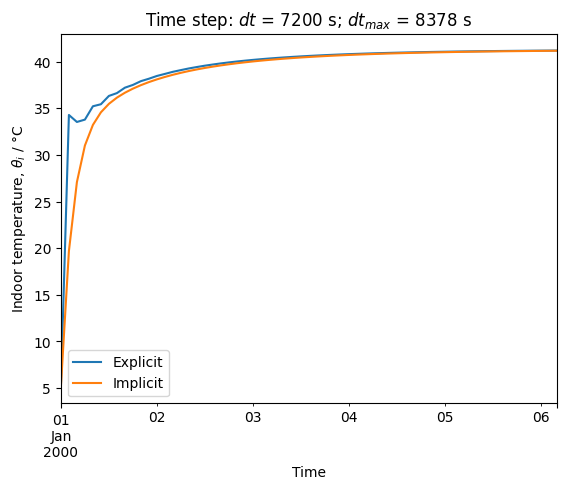

In [36]:
# plot results
y_exp_θ6 = y_exp.iloc[:, 1]
y_imp_θ6 = y_imp.iloc[:, 1]

y = pd.concat([y_exp_θ6, y_imp_θ6], axis=1, keys=['Explicit', 'Implicit'])
# Flatten the two-level column labels into a single level
y.columns = y.columns.get_level_values(0)

ax = y.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Indoor temperature, $\\theta_i$ / °C')
ax.set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {Δtmax:.0f} s')
plt.show()

#### 8.5.2 Controlled model

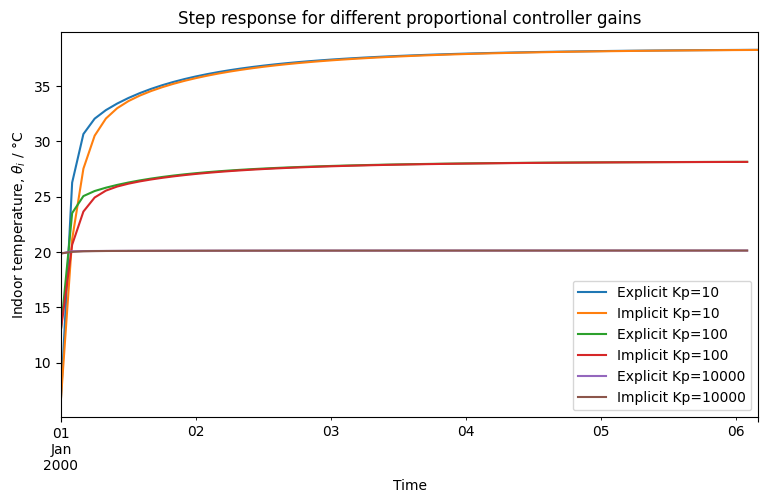

In [37]:
results = pd.DataFrame(index=time)

# Use the smaller time step to ensure stability
imposed_time_step = True

for Kp in [10, 100, 10000]:
    TC['G']['q7'] = Kp
    [As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)
    
    # Eigenvalues analysis
    λ = np.linalg.eig(As)[0]

    # time step
    Δtmax = 2 * min(-1. / λ)    # max time step for stability of Euler explicit mentioned before
    Δt = 3600  # imposed time step smaller than Δtmax

    if imposed_time_step:
        dt = Δt
    else:
        dt = dm4bem.round_time(Δtmax)
    
    # settling time
    t_settle = 4 * max(-1 / λ)

    # duration: next multiple of 3600 s that is larger than t_settle
    duration = np.ceil(t_settle / 3600) * 3600

    # time vector
    n = int(np.floor(duration / dt))    # number of time steps

    # DateTimeIndex starting at "00:00:00" with a time step of dt
    time = pd.date_range(start="2000-01-01 00:00:00",
                            periods=n, freq=f"{int(dt)}s")

    To_tv = To * np.ones(n)        # outdoor temperature
    Ti_sp_tv = Ti_sp * np.ones(n)     # indoor temperature set point
    Qa_tv = 80 * np.ones(n)          # auxiliary heat sources
    Φo_1_tv = Φo_1 * np.ones(n)     # solar radiation absorbed by the outdoor surface of the noninsulated wall
    Φi_1_tv = Φi_1 * np.ones(n)     # solar radiation absorbed by the indoor surface of the wall
    Φo_2_tv = Φo_2 * np.ones(n)     # solar radiation absorbed by the indoor surface of the insulated wall
    Φi_2_tv = Φi_2 * np.ones(n)     # solar radiation absorbed by the outdoor surface of the wall
    Φa_tv = Φa * np.ones(n)         # solar radiation absorbed by the glass

    data = {'To': To_tv, 'Ti_sp': Ti_sp_tv, 'Φo_1': Φo_1_tv, 'Φi_1': Φi_1_tv, 'Φo_2': Φo_2_tv, 'Φi_2': Φi_2_tv, 'Qa': Qa_tv, 'Φa': Φa_tv}
    input_data_set = pd.DataFrame(data, index=time)

    # inputs in time from input_data_set
    u = dm4bem.inputs_in_time(us, input_data_set)


    # Initial conditions
    θ_exp = pd.DataFrame(index=time, columns=As.columns, dtype=float)
    θ_imp = pd.DataFrame(index=time, columns=As.columns, dtype=float)

    θ_exp.iloc[0] = θ0
    θ_imp.iloc[0] = θ0

    I = np.eye(As.shape[0])

    # Time integration
    for k in range(u.shape[0] - 1):
        θ_exp.iloc[k + 1] = (I + dt * As) @ θ_exp.iloc[k] + dt * Bs @ u.iloc[k]

        θ_imp.iloc[k + 1] = np.linalg.inv(I - dt * As) @ (
            θ_imp.iloc[k] + dt * Bs @ u.iloc[k]
        )

    # Outputs
    y_exp = (Cs @ θ_exp.T + Ds @ u.T).T
    y_imp = (Cs @ θ_imp.T + Ds @ u.T).T

    # Store indoor temperature θ6
    results[f'Explicit Kp={Kp}'] = y_exp.iloc[:, 1]
    results[f'Implicit Kp={Kp}'] = y_imp.iloc[:, 1]

# Plot comparison
ax = results.plot(figsize=(9, 5))
ax.set_xlabel('Time')
ax.set_ylabel('Indoor temperature, $\\theta_i$ / °C')
ax.set_title('Step response for different proportional controller gains')
plt.show()

## 9. Optimization
### 9.1 Non-linear controller
In this section we study the effects of implementing a non-linear controller that can adapt to temperature changes over time.


In [127]:
def control_for_TC(controller, period, TC, weather_inputs, dt=30,
                   nonlinear_controller=True, solar_protection=False):
    """
    Simulates the full TC model with optional nonlinear controller.

    controller:
        string containing controller logic, executed at every time step.

    period:
        tuple/list with start and end date strings, e.g.
        ('2000-07-01', '2000-07-07')

    TC:
        full thermal circuit dictionary: A, G, C, b, f, y

    weather_inputs:
        DataFrame with columns:
        To, Φo_1, Φi_1, Qa, Φo_2, Φi_2, Φa

    dt:
        simulation time step in seconds
    """

    # Copy TC so original model is not modified
    TC_sim = {
        'A': TC['A'].copy(),
        'G': TC['G'].copy(),
        'C': TC['C'].copy(),
        'b': TC['b'].copy(),
        'f': TC['f'].copy(),
        'y': TC['y'].copy()
    }

    # Disable old linear controller branch
    TC_sim['G']['q7'] = 0

    # State-space model
    [As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC_sim)

    # Eigenvaleus analysis
    # ====================
    λ = np.linalg.eig(As)[0]

    dt_max = 2 * min(-1. / λ)
    dt_max = dm4bem.round_time(dt_max)
    dm4bem.print_rounded_time('dt_max', dt_max)

    # Simulation with weather data
    # ============================
    # Start / end time
    start_date = period[0]
    end_date = period[1]

    start_date = '2000-' + start_date
    end_date = '2000-' + end_date

    input_data_set = weather_inputs.loc[start_date:end_date].copy()

    # Temperature setpoint schedule
    Ti_day, Ti_night = 20, 16

    Ti_sp = pd.Series(
        [Ti_day if 6 <= hour <= 22 else Ti_night
        for hour in input_data_set.index.hour],
        index=input_data_set.index
    )

    input_data_set['Ti_sp'] = Ti_sp


    # Time integration
    # ----------------
    # Resample hourly data to time step dt
    input_data_set = input_data_set.resample(
        str(dt) + 'S').interpolate(method='linear')

    # Get input from input_data_set
    u = dm4bem.inputs_in_time(us, input_data_set)

    # initial conditions
    θ0 = 20.0                   # initial temperatures
    θ_exp = pd.DataFrame(index=u.index)
    θ_exp[As.columns] = θ0      # Fill θ with initial valeus θ0

    I = np.eye(As.shape[0])

    # Time integration
    for k in range(1, u.shape[0] - 1):
        if nonlinear_controller:
            exec(controller)

        θ_exp.iloc[k + 1] = (
            (I + dt * As) @ θ_exp.iloc[k]
            + dt * Bs @ u.iloc[k]
        )

    # Outputs
    y = (Cs @ θ_exp.T + Ds @ u.T).T

    # HVAC heat flow
    if nonlinear_controller:
        q_HVAC = u['θ6']
    else:
        q_HVAC = pd.Series(0, index=u.index)

    # Results dataframe
    data = pd.DataFrame({
        'To': input_data_set['To'],
        'θi': y['θ6'] if 'θ6' in y.columns else θ_exp['θ6'],
        'q_HVAC': q_HVAC
    })

    # Average HVAC power demand, treating negative q as positive
    average_q_needed = data['q_HVAC'].abs().mean()
    print(f"Average q needed: {average_q_needed:.2f} W")


    # Plot
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

    data[['To', 'θi']].plot(
        ax=axs[0],
        ylabel='Temperature, θ / °C'
    )
    axs[0].legend(['Outdoor temperature', 'Indoor temperature'])
    axs[0].grid(True)

    data[['q_HVAC']].plot(
        ax=axs[1],
        ylabel='Heat flow, q / W'
    )
    axs[1].set(xlabel='Time')
    axs[1].legend(['HVAC'])
    axs[1].grid(True)

    plt.show()


### 9.1.1 Free running
The first part is to see how the building behaves during free running conditions where the HVAC-system is turned off.

dt_max = 7200 s = 2.0 h
Average q needed: 0.00 W


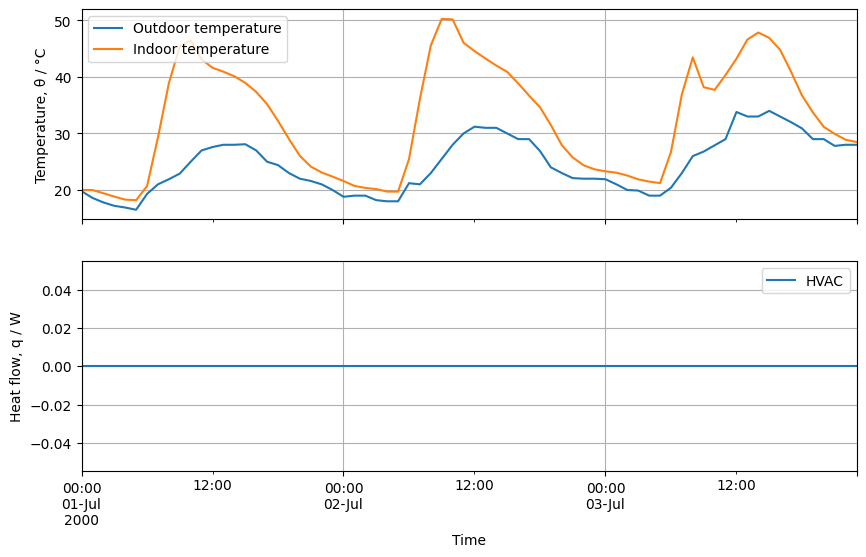

In [128]:
period = ('07-01', '07-03')

free_running = """
u.loc[u.index[k], 'θ6'] = 0
"""

control_for_TC(
    free_running,
    period,
    TC,
    weather_inputs,
    dt=3600,
    nonlinear_controller=True
)

### 9.1.2 Heating
For this section, a simulation during winter days is done, when heating is nessesary to maintain room temperature. During daytime, the temperature should be set to 20 degrees while during the night, a lower temperature of 15 degrees is allowed.

dt_max = 7200 s = 2.0 h
Average q needed: 752.76 W


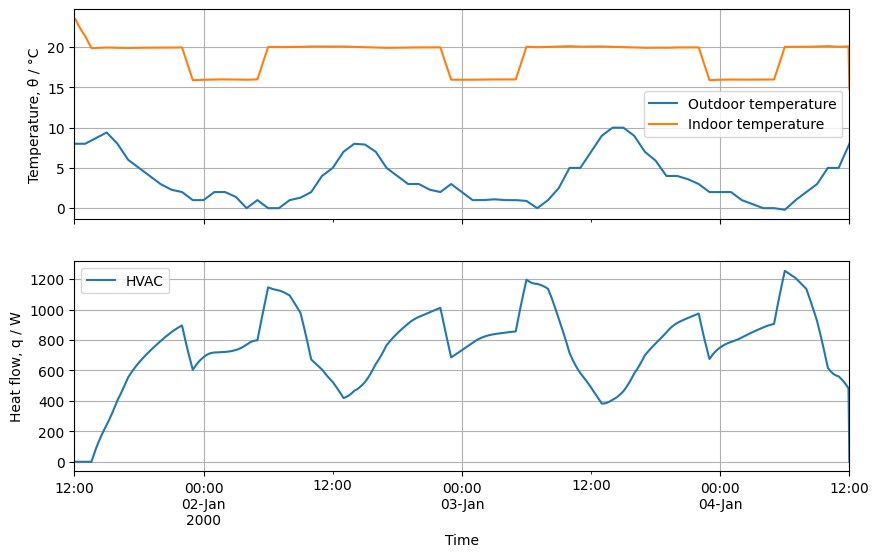

In [129]:
heating = """
Tisp = input_data_set.loc[u.index[k], 'Ti_sp']
Kpp = 90

# Estimate indoor temperature
Ti = Cs.loc['θ6'] @ θ_exp.iloc[k - 1] + Ds.loc['θ6'] @ u.iloc[k]

if Tisp < Ti:
    u.loc[u.index[k], 'θ6'] = 0.0
else:
    u.loc[u.index[k], 'θ6'] = Kpp * (Tisp - Ti)
"""

period = ['01-01 12:00:00', '01-04 12:00:00']

control_for_TC(
    heating,
    period,
    TC,
    weather_inputs,
    dt=300,
    nonlinear_controller=True
)

### 9.1.3 Cooling
For summer days when cooling is needed, a dead band controller can be used to allow for shorter temperature increases (here 5 degrees) to save energy. 

dt_max = 7200 s = 2.0 h
Average q needed: 670.16 W


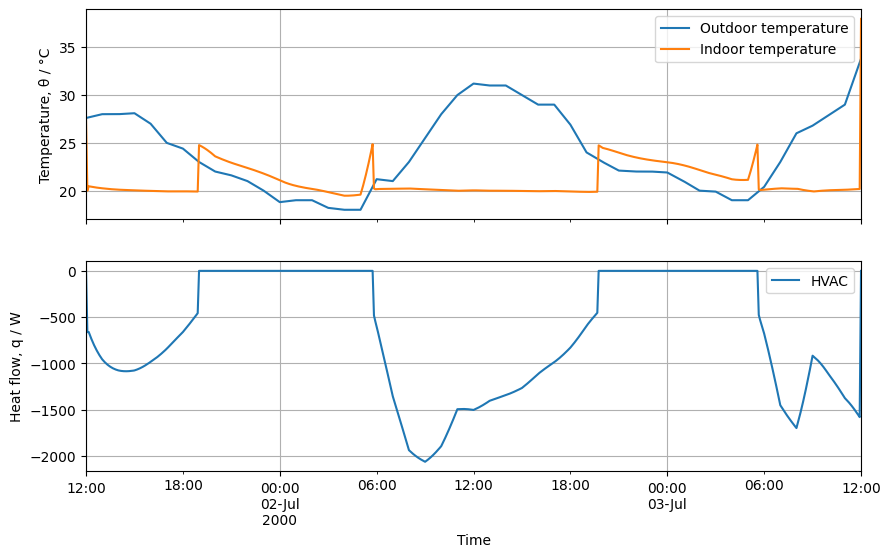

In [130]:
cooling = """
Tisp = 20   # indoor setpoint temperature, °C
Δθ = 5      # temperature deadband, °C
Kpp = 90   # controller gain

# Estimate indoor temperature.
Ti = Cs.loc['θ6'] @ θ_exp.iloc[k - 1] + Ds.loc['θ6'] @ u.iloc[k]

if Ti < Tisp + Δθ:
    u.loc[u.index[k], 'θ6'] = 0.0
else:
    u.loc[u.index[k], 'θ6'] = Kpp * (Tisp - Ti)
"""

period = ['07-01 12:00:00', '07-03 12:00:00']

control_for_TC(
    cooling,
    period,
    TC,
    weather_inputs,
    dt=300,
    nonlinear_controller=True
)

### 9.1.4 Heating and cooling
The final step is to implement both heating and cooling, which is often needed during spring and fall where the temperature varies both above and below room temperature.

dt_max = 7200 s = 2.0 h
Average q needed: 398.58 W


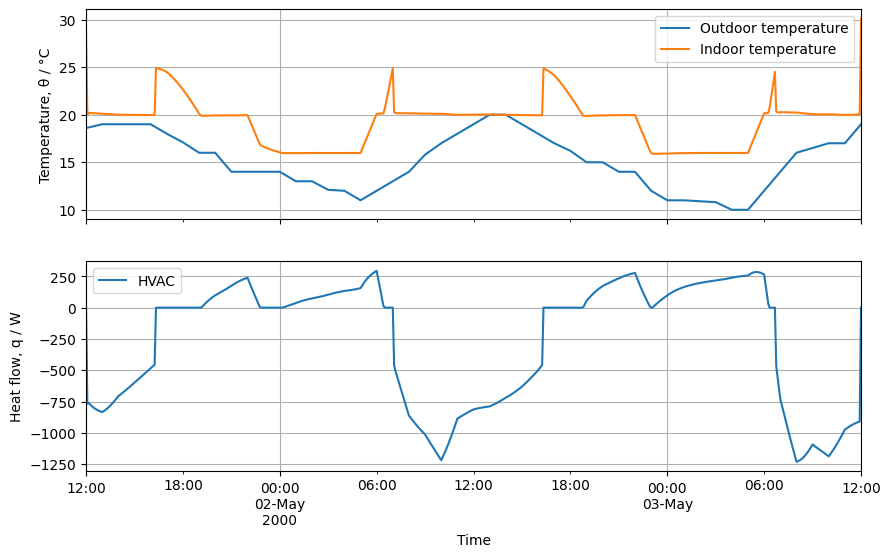

In [131]:
heat_cool = """
Tisp = input_data_set['Ti_sp'].iloc[k]   # indoor setpoint temperature, °C
Δθ = 5                                   # temperature deadband, °C
Kpp = 90                                # controller gain

# Estimate indoor temperature
Ti = Cs.loc['θ6'] @ θ_exp.iloc[k - 1] + Ds.loc['θ6'] @ u.iloc[k]

if Tisp < Ti < Tisp + Δθ:
    u.loc[u.index[k], 'θ6'] = 0.0
else:
    u.loc[u.index[k], 'θ6'] = Kpp * (Tisp - Ti)
"""

period = ['05-01 12:00:00', '05-03 12:00:00']

control_for_TC(
    heat_cool,
    period,
    TC,
    weather_inputs,
    dt=300,
    nonlinear_controller=True
)

The optimal Kp value for all these simulatins was found to be around Kpp = 90
### 9.2 Futher optimization

There are two main points of optimization left to study. The first is solar protection, which in our case we will simulate as a blind on the window. The second is the ventilation rate, which we will study by changing the ACH value.

## 9.2.1 Solar protection
To simulate solar protection on the window in the form of window blinds, we will reduce the transmitted light into the room to 10\% of the original value. This is done by multiplying the transmitted light by 0.1.

dt_max = 7200 s = 2.0 h
Average q needed: 319.46 W


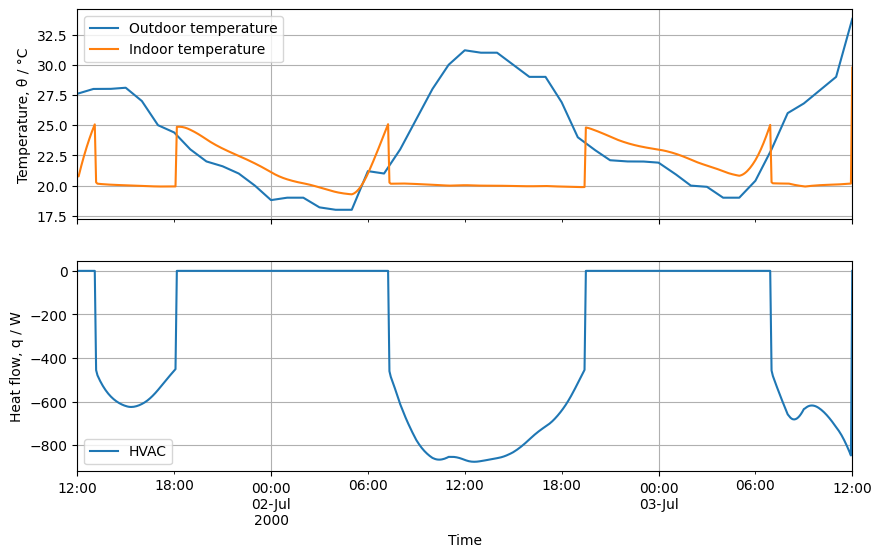

In [154]:
solar_protection = """
Tisp = input_data_set['Ti_sp'].iloc[k]   # indoor setpoint temperature, °C
Δθ = 5                                   # temperature deadband, °C
Kpp = 90                                # controller gain

# Estimate current indoor temperature
Ti = Cs.loc['θ6'] @ θ_exp.iloc[k] + Ds.loc['θ6'] @ u.iloc[k]


# Cooling control
if Ti <= Tisp + Δθ:
    u.loc[u.index[k], 'θ6'] = 0.0
else:
    for col in ['θ5', 'θ8']:
        u.loc[u.index[k], col] *= 0.1
    u.loc[u.index[k], 'θ6'] = min(Kpp * (Tisp - Ti), 0.0)

"""

period = ['07-01 12:00:00', '07-03 12:00:00']

control_for_TC(
    cooling,
    period,
    TC,
    weather_inputs,
    dt=300,
    nonlinear_controller=True,
    solar_protection=True
)

### 9.2.2 Passive cooling

Now, passive cooling through ventilation can be added on top of the solar protection. This will be done by having the possiblility to increase the ACH by 2. 


dt_max = 7200 s = 2.0 h
Average q needed: 84.91 W


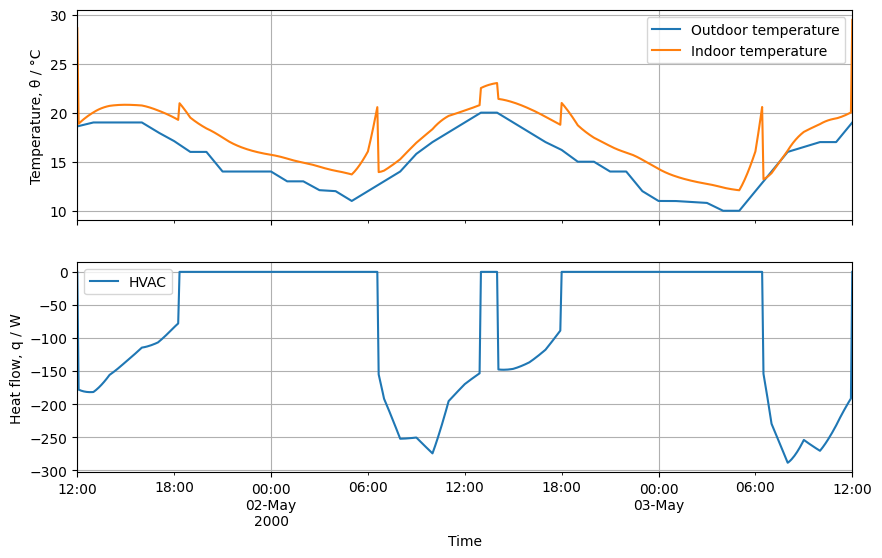

In [222]:
passive_cooling = """
Tisp = input_data_set['Ti_sp'].iloc[k]  # indoor setpoint temperature, °C
Δθ = 1.0                    # temperature deadband, °C

# ventilation flow rate
Va = l**3                   # m³, volume of air
ACH = 2.0                  # 1/h, additional air changes per hour
Va_dot = ACH / 3600 * Va    # m³/s, air flow rate
G_free = ρ_air * c_air * Va_dot

# Estimate indoor and outdoor temperatures
Ti = Cs.loc['θ6'] @ θ_exp.iloc[k] + Ds.loc['θ6'] @ u.iloc[k]
To = input_data_set.loc[u.index[k], 'To']

# passive cooling heat flow
q_free = G_free * (To - Ti)

if Ti < Tisp + Δθ:
    u.loc[u.index[k], 'θ6'] = 0.0
else:
    u.loc[u.index[k], 'θ6'] = 0.0

    if To < Tisp:
        u.loc[u.index[k], 'θ6'] = q_free

    # solar protection
    for col in ['θ5', 'θ8']:
        u.loc[u.index[k], col] *= 0.1
"""

period = ['05-01 12:00:00', '05-03 12:00:00']

control_for_TC(
    passive_cooling,
    period,
    TC,
    weather_inputs,
    dt=300,
    nonlinear_controller=True
)

### 9.4 Results on optimization

A first thing to note is that the linear controller used before, where the mean temperatures were stuied, seems to be a good approximation. During winter, the linear controller calculated 717.61 W + 80 W = 797.61 W of heating power, and the non-linear controller calculated an average of 736.59 W. During summer, the linear controller calculated -692.23 W + 80 W = -612.23 W of cooling power, and the non-linear controller calculated an average of 670.16 W. This shows that the linear controller is a good approximation of the non-linear controller for summer and winter, based on these days we have simulated. However, during spring and fall, the average temperature is very mild, yet in the real case, the outdoor temperature can fluxuate a lot, between 10 and 20 degrees. This is why the non-linear controller is more accurate here, since regulating the temperature during the fluxuations. The linear controller has found some sort of minima here (with outdoor temperature and solar radiation), needing only an average of 40.32 W, while the non-linear requires 10x that amount. Furthermore, the deadband controller works quite well, yet it causes spikes in the indoor air temperature at some occations when the temperature is close to the setpoint. The optimal value of Kp for these simulations was 90. Higher or significanly higher values (such as our previous 1e3) causes complete overregulation and extreame indoor room temperatures, and lower values (such as 10) causes underregulation.

The solar protection was effective for the summer days it reduced the cooling needed by half. This is a clear and obvious implementation to buildings that needs to function during high outdoor temperatures and solar radiation. The passive cooling was also effective, and could reduce the cooling and heating needed by 8 times together with solar protection. However, using an implementation as simple as this one, the temperature was hard to controll, leading to it following the outdoor temperature quite closely. An ideal scenario has all four types of controllers together, one for heating, one for cooling, one for solar protection and one for passive cooling. This would give the best results, and the most efficient regulation of the indoor temperature.